In [ ]:
import numpy as np
import pandas as pd

# Task 0
Read the dataset from csv file & perform data cleaning - remove all rows, which contains `?` in some columns.
Also check for data correctness (salary & salary $K).

In [21]:
import pandas as pd


df = pd.read_csv("/Users/khrypunov/PycharmProjects/py-adult-data-analysis/data/adult.csv", index_col=0)

df_cleaned = df[~df.apply(lambda row: row.astype(str).str.contains(r'\?').any(), axis=1)].copy()

df_cleaned['salary K$'] = pd.to_numeric(df_cleaned['salary K$'], errors='coerce')

def is_salary_correct(row):
    if pd.isna(row['salary K$']):
        return False
    if row['salary'] == '<=50K' and row['salary K$'] <= 50:
        return True
    elif row['salary'] == '>50K' and row['salary K$'] > 50:
        return True
    else:
        return False

df_valid = df_cleaned[df_cleaned.apply(is_salary_correct, axis=1)]
print(df_valid)




       age         workclass   education      marital-status  \
0       39         State-gov   Bachelors       Never-married   
1       50  Self-emp-not-inc   Bachelors  Married-civ-spouse   
2       38           Private     HS-grad            Divorced   
3       53           Private        11th  Married-civ-spouse   
4       28           Private   Bachelors  Married-civ-spouse   
...    ...               ...         ...                 ...   
32556   27           Private  Assoc-acdm  Married-civ-spouse   
32557   40           Private     HS-grad  Married-civ-spouse   
32558   58           Private     HS-grad             Widowed   
32559   22           Private     HS-grad       Never-married   
32560   52      Self-emp-inc     HS-grad  Married-civ-spouse   

              occupation   relationship   race     sex  hours-per-week  \
0           Adm-clerical  Not-in-family  White    Male              40   
1        Exec-managerial        Husband  White    Male              13   
2      Ha

# Task 1
Print the count of men and women in the dataset.

In [17]:
sex_counts = df_valid['sex'].value_counts()

print(sex_counts)

Male      20380
Female     9782
Name: sex, dtype: int64


# Task 2
Find the average age of men in dataset

In [18]:
men = df_valid[df_valid['sex'] == 'Male']

average_age_men = men['age'].mean()

print(average_age_men)

39.18400392541707


# Task 3
Get the percentage of people from Poland (native-country)

In [19]:
total_people = len(df_valid)

poland_people = len(df_valid[df_valid["native-country"] == "Poland"])

percentage_poland = (poland_people / total_people) * 100

print(percentage_poland)

0.18566408063125786


# Task 4
Get the mean and standard deviation of the age for people who earn > 50K per year. After this, get it for those who earn <= 50K.

In [20]:
high_earners = df_valid[df_valid['salary'] == '>50K']
mean_high = high_earners['age'].mean()
std_high = high_earners['age'].std()

low_earners = df_valid[df_valid['salary'] == '<=50K']
mean_low = low_earners['age'].mean()
std_low = low_earners['age'].std()

print(mean_high, std_high)

print(mean_low, std_low)

43.95911028236548 10.269632835673852
36.60806038668668 13.464631257161633


# Task 5
Check, if there are some people without higher education (education: Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters, Doctorate), but with > 50K salary

In [23]:
higher_education = [
    'Bachelors', 'Prof-school', 'Assoc-acdm',
    'Assoc-voc', 'Masters', 'Doctorate'
]

high_income_no_higher_ed = df_valid[
    (~df_valid['education'].isin(higher_education)) & (df_valid['salary'] == '>50K')
]

count = len(high_income_no_higher_ed)

print(count)

3178


# Task 6
Get the statistics of age for each type of education. Use `groupby` and `describe` for this.

In [22]:
age_stats_by_education = df_valid.groupby('education')['age'].describe()

print(age_stats_by_education)

               count       mean        std   min   25%   50%   75%   max
education                                                               
10th           820.0  37.897561  16.225795  17.0  23.0  36.0  52.0  90.0
11th          1048.0  32.363550  15.089307  17.0  18.0  28.5  43.0  90.0
12th           377.0  32.013263  14.373710  17.0  19.0  28.0  41.0  79.0
1st-4th        151.0  44.622517  14.929051  19.0  33.0  44.0  56.0  81.0
5th-6th        288.0  41.649306  14.754622  17.0  28.0  41.0  53.0  82.0
7th-8th        557.0  47.631957  15.737479  17.0  34.0  49.0  60.0  90.0
9th            455.0  40.303297  15.335754  17.0  28.0  38.0  53.0  90.0
Assoc-acdm    1008.0  37.286706  10.509755  19.0  29.0  36.0  44.0  90.0
Assoc-voc     1307.0  38.246366  11.181253  19.0  30.0  37.0  45.0  84.0
Bachelors     5044.0  38.641554  11.577566  19.0  29.0  37.0  46.0  90.0
Doctorate      375.0  47.130667  11.471727  24.0  39.0  47.0  54.0  80.0
HS-grad       9840.0  38.640955  13.067730  17.0  2

# Task 7
Compare the married and non-married men salaries. Who earns more? (>50K or <=50K)
Married men are those, whom `marital-status` starts with "Married". Others are not.

In [25]:

men = df_valid[df_valid['sex'] == 'Male'].copy()

men['married'] = men['marital-status'].str.startswith('Married')

salary_comparison = men.groupby(['married', 'salary']).size().unstack(fill_value=0)

print(salary_comparison)


salary   <=50K  >50K
married             
False     6932   673
True      7052  5723


# Task 8
Get the max hours per week some person works. How many people works the same amount of hours per week?

In [26]:
max_hours = df_valid['hours-per-week'].max()

num_people = (df_valid['hours-per-week'] == max_hours).sum()


print(max_hours)
print(num_people)


99
78


# Task 9
Analyze the correlation between data in dataset. Understand connected fields in it and print highlight thier connection.

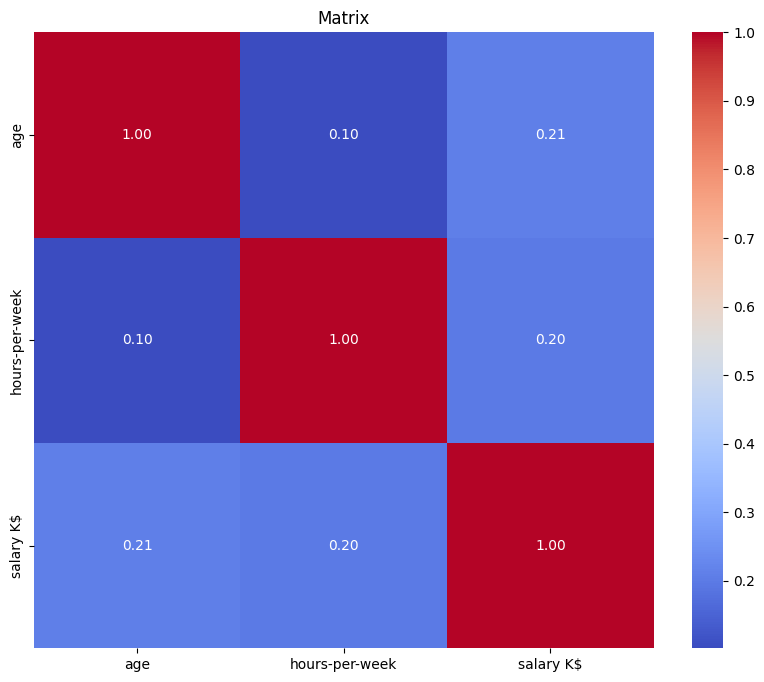

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = df_valid.select_dtypes(include='number')

correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrix")
plt.show()
